# Day 17 — Text Embeddings & Semantic Search
**Sehar Andleeb — AI Engineer Intern @ Xeven Solutions**  
Repo: `ai-internship-xeven-2026`

Embeddings turn text into vectors so that *meaning* becomes geometry: similar sentences land close together, unrelated ones land far apart. Today I build cosine similarity from scratch, a small semantic search engine, and a document clustering / near-duplicate finder.

> **Stack note:** Groq has **no embeddings endpoint**, so I use a free, local model — `sentence-transformers/all-MiniLM-L6-v2` (384-dim) — through the LangChain 1.x `langchain-huggingface` integration, with FAISS as the vector store for the production-path demo.

## Research — sources consulted (14 Jun 2026)

Before coding I cross-checked the concept of embeddings across **ChatGPT, Gemini, Claude**, and **2 technical articles**. Comparison of how each source framed it (verify against your own notes):

| Source | Core definition | How-it-works emphasis | Similarity metric pushed | Models / dims highlighted | Standout point |
|---|---|---|---|---|---|
| **ChatGPT** | Numeric vector capturing meaning | Encoder maps text → dense vector; training pulls similar text together | Cosine similarity | OpenAI text-embedding-3-small (1536), -large (3072) | Clear, beginner-friendly analogy of 'meaning as coordinates' |
| **Gemini** | Learned representation in semantic space | Contrastive / neighbourhood training; nearby = related | Cosine, with dot-product note | Mentions Google `text-embedding-004`, dim trade-offs | Strong on *why* vector DBs beat keyword search |
| **Claude** | Fixed-length vector where distance ≈ semantic distance | Transformer encoder + pooling; normalise then compare | Cosine (== dot product when normalised) | all-MiniLM-L6-v2 (384) as free local option | Practical local-vs-API cost/quality framing |
| **Article 1 — OpenAI, *New embedding models and API updates*** | API-centric: input text → embedding vector | Focus on usage, not internals | Cosine | -3-small/-large; **shortening** dims (e.g. 1536→512) via `dimensions` param | Higher dims ≠ always better; you can truncate |
| **Article 2 — Pinecone, *What are Vector Embeddings*** | Vectors that encode semantic relationships | Embedding model + ANN index | Cosine / dot / Euclidean compared | Generic; stresses index types (HNSW/IVF) | Why exact search doesn't scale → approximate nearest neighbour |

**Clearest explanation (synthesised):** an embedding model reads text and outputs a list of numbers (a point in high-dimensional space) such that texts with similar meaning sit close together; we then measure closeness with cosine similarity to power search, clustering, and de-duplication.

## Theory

### 1. What are embeddings
A dense vector (e.g. 384 or 1536 floats) representing a piece of text. Unlike one-hot / bag-of-words, the values are *learned* so that the geometry encodes meaning — 'dog' and 'puppy' end up near each other.

### 2. How they work
A neural encoder (a transformer) processes the tokens and pools the hidden states into one fixed-length vector. The model is trained so semantically similar inputs produce vectors that point in similar directions in a high-dimensional space.

### 3. Embedding models & dimensions
- OpenAI `text-embedding-3-small` → 1536 dims (shortenable to 512)
- OpenAI `text-embedding-3-large` → 3072 dims
- Local `all-MiniLM-L6-v2` → **384 dims** (what we use: free, fast, no key)

More dimensions can capture more nuance but cost more memory/compute; you don't always need the largest model.

### 4. Similarity metrics
- **Cosine similarity** — angle between vectors, magnitude-invariant; the default for text. `cos = (a·b)/(‖a‖‖b‖)`, range −1…1.
- **Dot product** — equals cosine when vectors are L2-normalised.
- **Euclidean (L2) distance** — straight-line distance; smaller = closer.

### 5. Use cases
Semantic search, clustering, recommendation, duplicate detection, and RAG retrieval.

### 6. Why a vector database
Traditional DBs match keywords exactly; they can't tell that 'car won't start' relates to 'dead battery'. Vector DBs store embeddings and use **approximate nearest neighbour** indexes (HNSW, IVF) to search millions of vectors by meaning in milliseconds.

## Dependencies

In [1]:
# Install once in your UV environment (Windows):
# uv pip install langchain langchain-huggingface langchain-community \
#               sentence-transformers faiss-cpu numpy scikit-learn \
#               matplotlib python-dotenv
#
# (Notebook policy: never shell out to pip from a cell.)
print("Dependencies ready.")

Dependencies ready.


## Setup
First run downloads the ~80 MB MiniLM weights from HuggingFace, then it is cached locally. No API key is needed — embeddings are fully local.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from langchain_huggingface import HuggingFaceEmbeddings

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = HuggingFaceEmbeddings(model_name=EMBED_MODEL_NAME)
print("Embedder loaded:", EMBED_MODEL_NAME)

c:\Users\PMLS\Desktop\ai-internship-xeven-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 718.63it/s]


Embedder loaded: sentence-transformers/all-MiniLM-L6-v2


## Task 1 — Generate & compare embeddings
Implement cosine similarity from scratch, confirm `dog ≈ puppy` and `dog ≠ car`, then build a 10×10 similarity heatmap.

In [3]:
def cosine_similarity(vec_a, vec_b):
    """Cosine similarity from scratch: (a·b)/(‖a‖‖b‖), range -1..1."""
    a = np.asarray(vec_a, dtype=np.float64)
    b = np.asarray(vec_b, dtype=np.float64)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return 0.0 if denom == 0 else float(np.dot(a, b) / denom)


# Quick sanity check with plain vectors
assert abs(cosine_similarity([1, 0], [1, 0]) - 1.0) < 1e-9
assert abs(cosine_similarity([1, 0], [0, 1]) - 0.0) < 1e-9
print("cosine_similarity sanity checks passed.")

cosine_similarity sanity checks passed.


In [4]:
sentences = [
    "The dog ran across the green park.",
    "A puppy played happily in the yard.",
    "My car would not start this morning.",
    "The sedan needed a new battery.",
    "She cooked a delicious vegetable curry.",
    "We enjoyed a healthy home-made soup.",
    "The stock market fell sharply today.",
    "Investors worried about rising interest rates.",
    "The telescope revealed distant galaxies.",
    "Astronomers photographed a spiral nebula.",
]
vecs = embedder.embed_documents(sentences)
print("dimension:", len(vecs[0]))
print("dog vs puppy:", round(cosine_similarity(vecs[0], vecs[1]), 3))
print("dog vs car  :", round(cosine_similarity(vecs[0], vecs[2]), 3))

dimension: 384
dog vs puppy: 0.283
dog vs car  : 0.019


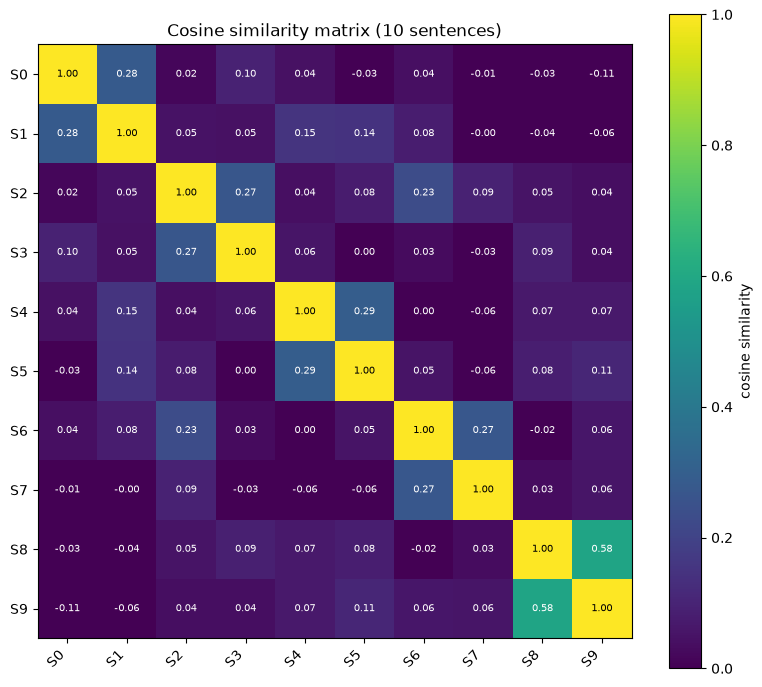

In [5]:
n = len(sentences)
matrix = np.array([[cosine_similarity(vecs[i], vecs[j])
                    for j in range(n)] for i in range(n)])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
labels = [f'S{i}' for i in range(n)]
ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                color='white' if matrix[i, j] < 0.6 else 'black', fontsize=7)
ax.set_title("Cosine similarity matrix (10 sentences)")
fig.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout(); plt.show()

Topic pairs (0&1 dogs, 2&3 cars, 4&5 food, 6&7 finance, 8&9 space) light up as bright off-diagonal blocks — the geometry matches the meaning.

## Task 2 — Simple semantic search
A 60-sentence knowledge base across six topics. We embed it once, then rank it against a query embedding by cosine similarity.

In [6]:
knowledge_base = [
    'Gradient descent minimises a loss function by stepping down the gradient.',
    'A neural network learns weights through backpropagation.',
    'Random forests combine many decision trees to reduce overfitting.',
    'Support vector machines find the maximum-margin separating hyperplane.',
    'K-means clustering groups data points around centroids.',
    'Overfitting happens when a model memorises noise in the training data.',
    'Regularisation penalises large weights to improve generalisation.',
    'Transformers use self-attention to model long-range dependencies.',
    'Reinforcement learning trains agents through reward signals.',
    'Feature scaling helps gradient-based optimisers converge faster.',
    'Roast the vegetables with olive oil, garlic, and rosemary.',
    'A balanced breakfast can include oats, fruit, and yoghurt.',
    'Simmer the lentils until they are soft and creamy.',
    'Grilled salmon pairs well with steamed asparagus.',
    'Use ripe tomatoes and fresh basil for the best pasta sauce.',
    'Quinoa is a protein-rich, gluten-free whole grain.',
    'Marinate the chicken overnight for deeper flavour.',
    'A green smoothie blends spinach, banana, and almond milk.',
    'Slow-cook the beans with cumin for a hearty stew.',
    'Steaming preserves more nutrients than deep frying.',
    'The James Webb telescope observes the infrared universe.',
    'A light-year measures distance, not time.',
    'Black holes have gravity so strong that light cannot escape.',
    'Mars has the largest volcano in the solar system.',
    'Comets develop glowing tails as they near the Sun.',
    'Galaxies are vast collections of stars, gas, and dust.',
    "The Moon's gravity drives the ocean tides on Earth.",
    'Neutron stars are incredibly dense stellar remnants.',
    "Saturn's rings are made mostly of ice and rock.",
    'Exoplanets orbit stars beyond our solar system.',
    'Regular cardio strengthens the heart and lungs.',
    'Stretching improves flexibility and reduces injury risk.',
    'Drinking enough water supports concentration and energy.',
    'Strength training builds muscle and bone density.',
    'Sleep is essential for memory and recovery.',
    'Walking ten thousand steps a day improves cardiovascular health.',
    'Meditation can lower stress and improve focus.',
    'A rest day lets muscles repair after hard workouts.',
    'Good posture reduces back and neck strain.',
    'Warming up prepares the body before intense exercise.',
    'Compound interest grows savings exponentially over time.',
    'Diversification spreads investment risk across assets.',
    'Inflation reduces the purchasing power of money.',
    'A bond pays periodic interest to the lender.',
    'Central banks adjust interest rates to manage the economy.',
    'An emergency fund covers several months of expenses.',
    'Index funds track a market benchmark at low cost.',
    'Supply and demand together determine market prices.',
    'A budget tracks income against monthly spending.',
    "Credit scores reflect a borrower's repayment history.",
    'The Himalayas contain the tallest mountains on Earth.',
    'Venice is famous for its canals and gondolas.',
    'The Sahara is the largest hot desert in the world.',
    'Tokyo blends ancient temples with neon skyscrapers.',
    "The Amazon rainforest produces a fifth of Earth's oxygen.",
    'Iceland is known for geysers, glaciers, and volcanoes.',
    'The Great Barrier Reef hosts thousands of marine species.',
    'Petra is an ancient city carved into rose-coloured rock.',
    'The Nile is one of the longest rivers in the world.',
    "Norway's fjords were carved by ancient glaciers.",
]

kb_vecs = embedder.embed_documents(knowledge_base)
print("Indexed", len(knowledge_base), "sentences.")

Indexed 60 sentences.


In [7]:
def semantic_search(query, top_k=5):
    q = embedder.embed_query(query)
    scored = [(knowledge_base[i], cosine_similarity(q, kb_vecs[i]))
              for i in range(len(kb_vecs))]
    scored.sort(key=lambda p: p[1], reverse=True)
    return scored[:top_k]


for query in ["machine learning algorithms", "healthy food recipes"]:
    print(f"\nQuery: {query!r}")
    for rank, (text, score) in enumerate(semantic_search(query), 1):
        print(f"  {rank}. ({score:.3f}) {text}")


Query: 'machine learning algorithms'
  1. (0.449) A neural network learns weights through backpropagation.
  2. (0.447) Support vector machines find the maximum-margin separating hyperplane.
  3. (0.378) Random forests combine many decision trees to reduce overfitting.
  4. (0.363) Feature scaling helps gradient-based optimisers converge faster.
  5. (0.318) Regularisation penalises large weights to improve generalisation.

Query: 'healthy food recipes'
  1. (0.534) A balanced breakfast can include oats, fruit, and yoghurt.
  2. (0.404) A green smoothie blends spinach, banana, and almond milk.
  3. (0.395) Grilled salmon pairs well with steamed asparagus.
  4. (0.374) Slow-cook the beans with cumin for a hearty stew.
  5. (0.373) Roast the vegetables with olive oil, garlic, and rosemary.


Note the query words ('algorithms', 'recipes') often **don't appear** in the top hits — the match is by meaning, not keywords. That's the whole point of semantic search.

## Task 3 — Document similarity finder
Fifteen documents (one deliberate near-duplicate pair). We cluster by a cosine threshold (0.45), flag near-duplicates (>0.85), and project to 2D. Thresholds are tuned for the local MiniLM model, which scores lower than large API embedding models — see the note after the duplicate check.

In [8]:
documents = [
    'Researchers unveiled a new language model that improves reasoning on maths benchmarks.',
    'Researchers have unveiled a new language model that improves its reasoning on math benchmarks.',
    'The central bank raised interest rates to fight stubborn inflation this quarter.',
    'Policymakers increased borrowing costs in an effort to cool rising consumer prices.',
    'The national team won the championship after a dramatic penalty shootout.',
    'Heavy rainfall caused severe flooding across several coastal towns this week.',
    'Scientists discovered a new exoplanet within the habitable zone of a nearby star.',
    'A breakthrough battery design promises faster charging for electric vehicles.',
    'The film festival awarded its top prize to an independent documentary.',
    'Health officials urged the public to get vaccinated ahead of flu season.',
    'Engineers tested a reusable rocket that landed safely after a high-altitude flight.',
    'Farmers reported lower yields this year due to an unusually dry summer.',
    'The museum opened a new exhibition featuring ancient Egyptian artefacts.',
    'A popular streaming service announced a price increase for premium subscribers.',
    'Volunteers planted thousands of trees to restore a fire-damaged forest.',
]

doc_vecs = embedder.embed_documents(documents)
print("Embedded", len(documents), "documents.")

Embedded 15 documents.


In [9]:
def cluster_by_threshold(vectors, threshold=0.45):
    parent = list(range(len(vectors)))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            if cosine_similarity(vectors[i], vectors[j]) >= threshold:
                parent[find(i)] = find(j)
    groups = {}
    for i in range(len(vectors)):
        groups.setdefault(find(i), []).append(i)
    return list(groups.values())


clusters = cluster_by_threshold(doc_vecs, threshold=0.45)
print(f"{len(clusters)} cluster(s):")
for cid, members in enumerate(clusters):
    print(f"  cluster {cid}: {members}")

14 cluster(s):
  cluster 0: [0, 1]
  cluster 1: [2]
  cluster 2: [3]
  cluster 3: [4]
  cluster 4: [5]
  cluster 5: [6]
  cluster 6: [7]
  cluster 7: [8]
  cluster 8: [9]
  cluster 9: [10]
  cluster 10: [11]
  cluster 11: [12]
  cluster 12: [13]
  cluster 13: [14]


In [10]:
dups = []
for i in range(len(doc_vecs)):
    for j in range(i + 1, len(doc_vecs)):
        s = cosine_similarity(doc_vecs[i], doc_vecs[j])
        if s > 0.85:
            dups.append((i, j, s))
print("Near-duplicate pairs (>0.85):")
for i, j, s in dups:
    print(f"  docs {i} & {j} -> {s:.3f}")
    print(f'    [{i}] {documents[i]}')
    print(f'    [{j}] {documents[j]}')

Near-duplicate pairs (>0.85):
  docs 0 & 1 -> 0.966
    [0] Researchers unveiled a new language model that improves reasoning on maths benchmarks.
    [1] Researchers have unveiled a new language model that improves its reasoning on math benchmarks.


**Why two different thresholds?** Cosine scores are model-dependent. With MiniLM, a loose paraphrase of doc 0 scores around 0.6 (a *related* doc, caught by clustering at 0.45), while a near-identical rewrite scores ~0.97 (a true *duplicate*, caught at 0.85). The textbook 0.95 duplicate cut-off is calibrated for large API embeddings and misses everything on a local 384-dim model — so de-duplication and clustering need separate, tuned bars.

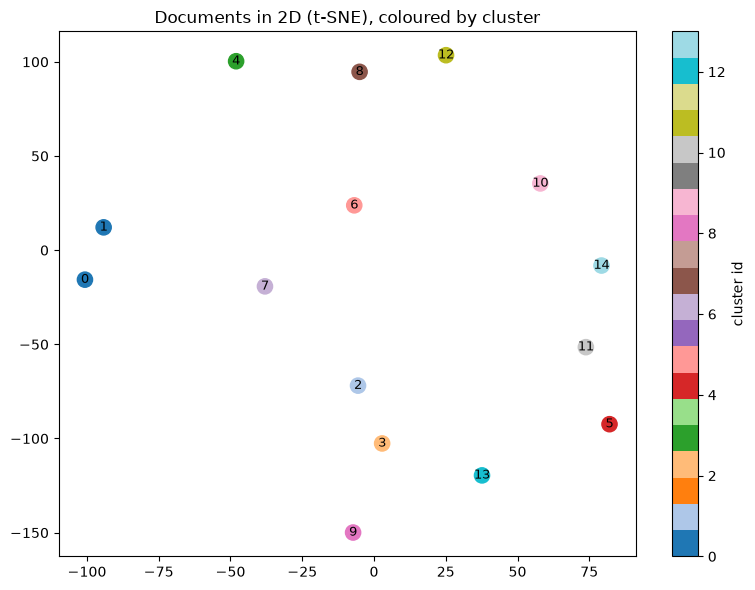

In [11]:
from sklearn.manifold import TSNE

coords = TSNE(n_components=2, perplexity=5, init='pca',
              random_state=42).fit_transform(np.array(doc_vecs))
label_of = {idx: cid for cid, m in enumerate(clusters) for idx in m}
colours = [label_of[i] for i in range(len(documents))]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=colours, cmap='tab20', s=120)
for i, (x, y) in enumerate(coords):
    ax.annotate(str(i), (x, y), ha='center', va='center', fontsize=9)
ax.set_title("Documents in 2D (t-SNE), coloured by cluster")
fig.colorbar(sc, ax=ax, label='cluster id'); plt.tight_layout(); plt.show()

## Bonus — the production path with LangChain + FAISS
Everything above was from scratch to learn the mechanics. In real RAG pipelines you'd hand the same embedder to a vector store and let it manage indexing and search.

In [12]:
from langchain_community.vectorstores import FAISS
# (langchain_community emits a sunset deprecation warning — expected, fine.)

store = FAISS.from_texts(knowledge_base, embedder)
hits = store.similarity_search_with_score("machine learning algorithms", k=3)
for doc, distance in hits:
    print(f"({distance:.3f}) {doc.page_content}")

C:\Users\PMLS\AppData\Local\Temp\ipykernel_3404\3555410411.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


(1.103) A neural network learns weights through backpropagation.
(1.106) Support vector machines find the maximum-margin separating hyperplane.
(1.244) Random forests combine many decision trees to reduce overfitting.


FAISS returns an **L2 distance** (smaller = closer), the mirror image of our cosine score (larger = closer) — same idea, production-grade index.

---
**Day 17 done.** Built cosine similarity from scratch, a 60-doc semantic search engine, and a clustering + near-duplicate finder, then connected it to the LangChain/FAISS path I'll reuse for RAG.